# Reading visual-language representations

**Input:** two GQA shirt-color questions with the original images and target boxes. **Model:** LLaVA-1.5-7B. **Tools:** Logit Lens, a fitted Tuned Lens, EmbedLens lexical neighbors, and Patchscopes.

**Run mode:** the default cells replay real completed model measurements from `snapshots/`, using the public library visualization API. Saved outputs are retained. Set `RERUN = True` only after installing the model dependencies and configuring the optional run below. These examples are demonstrations, not dataset-level reproductions.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (parent / "demos" / "common.py").is_file() and (parent / "pyproject.toml").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display
from vlm_probing import Prober
from vlm_probing.visualization import (plot_input, plot_lens_heatmap, plot_attention_comparison,
                                       plot_causal_heatmap, plot_intervention_curves)
from demos.common import ASSETS, load_snapshot, load_image, show_figure, gqa_input, target_ranks
RERUN = False  # Keep False for the bundled, genuinely measured offline results.
print("Offline replay of archived model measurements; no inference or training.")

Offline replay of archived model measurements; no inference or training.


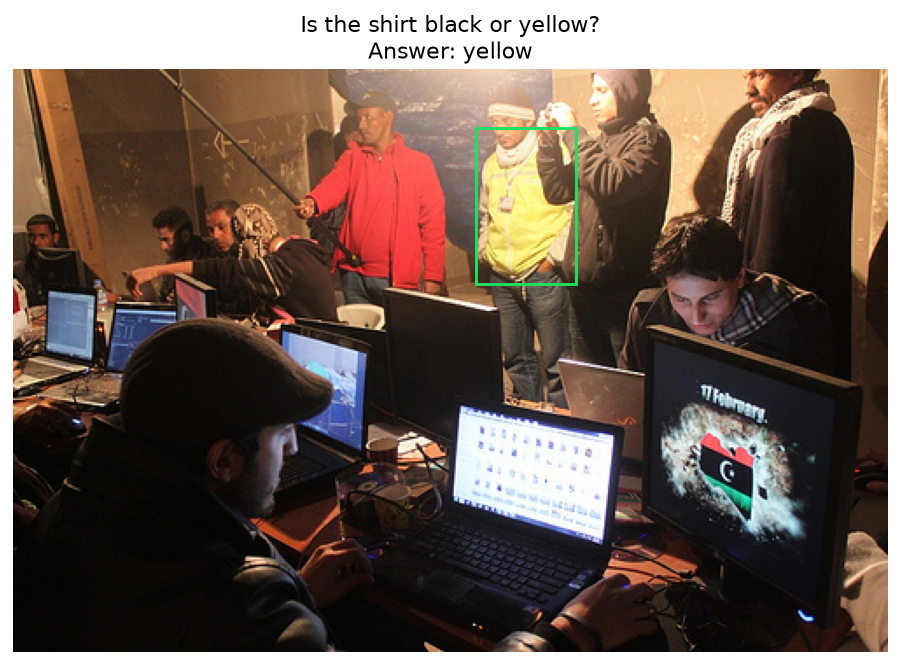

Native generated answer: Yellow


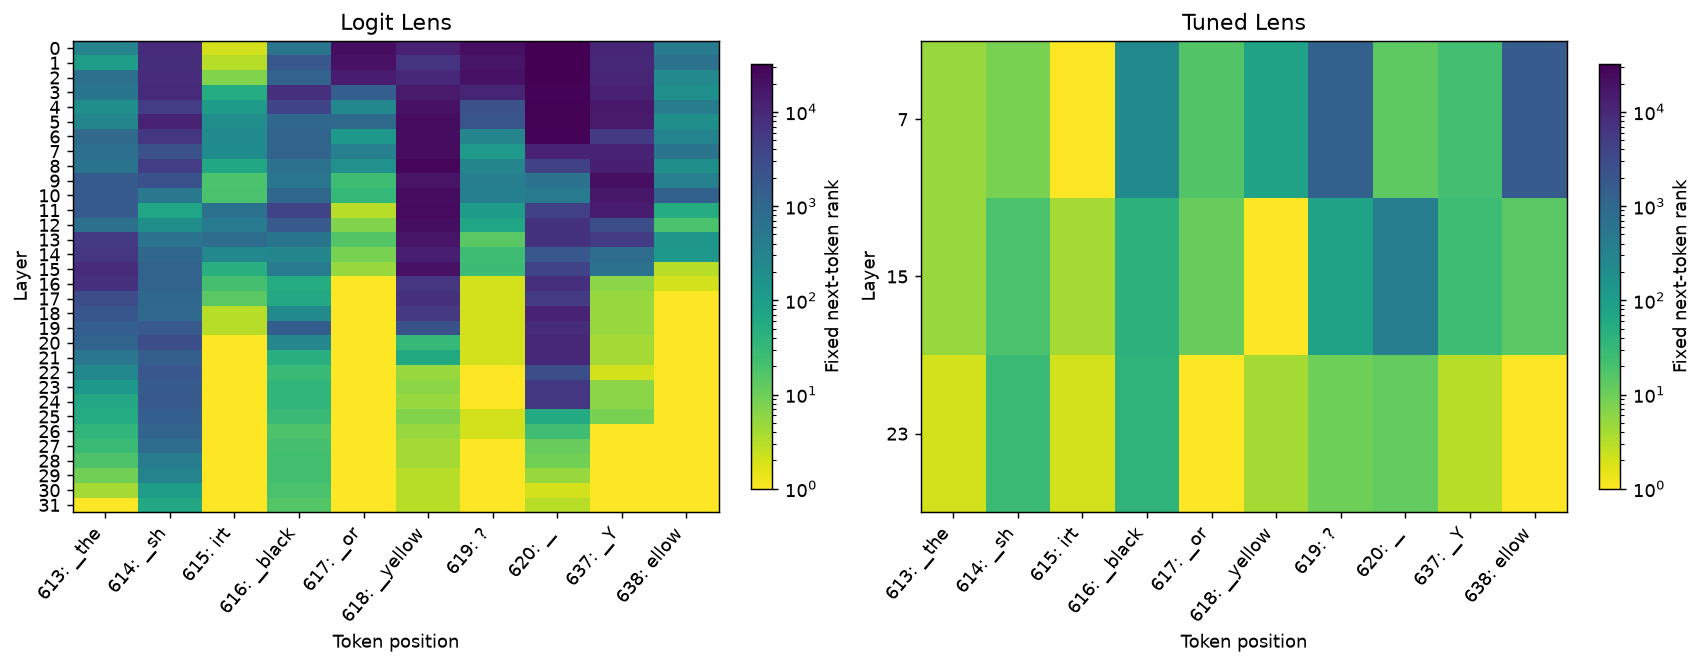

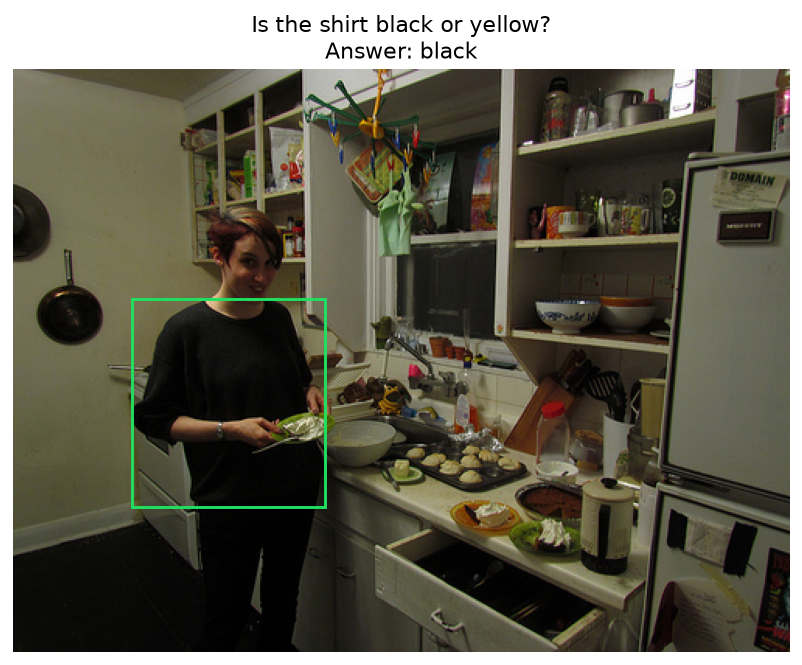

Native generated answer: Black


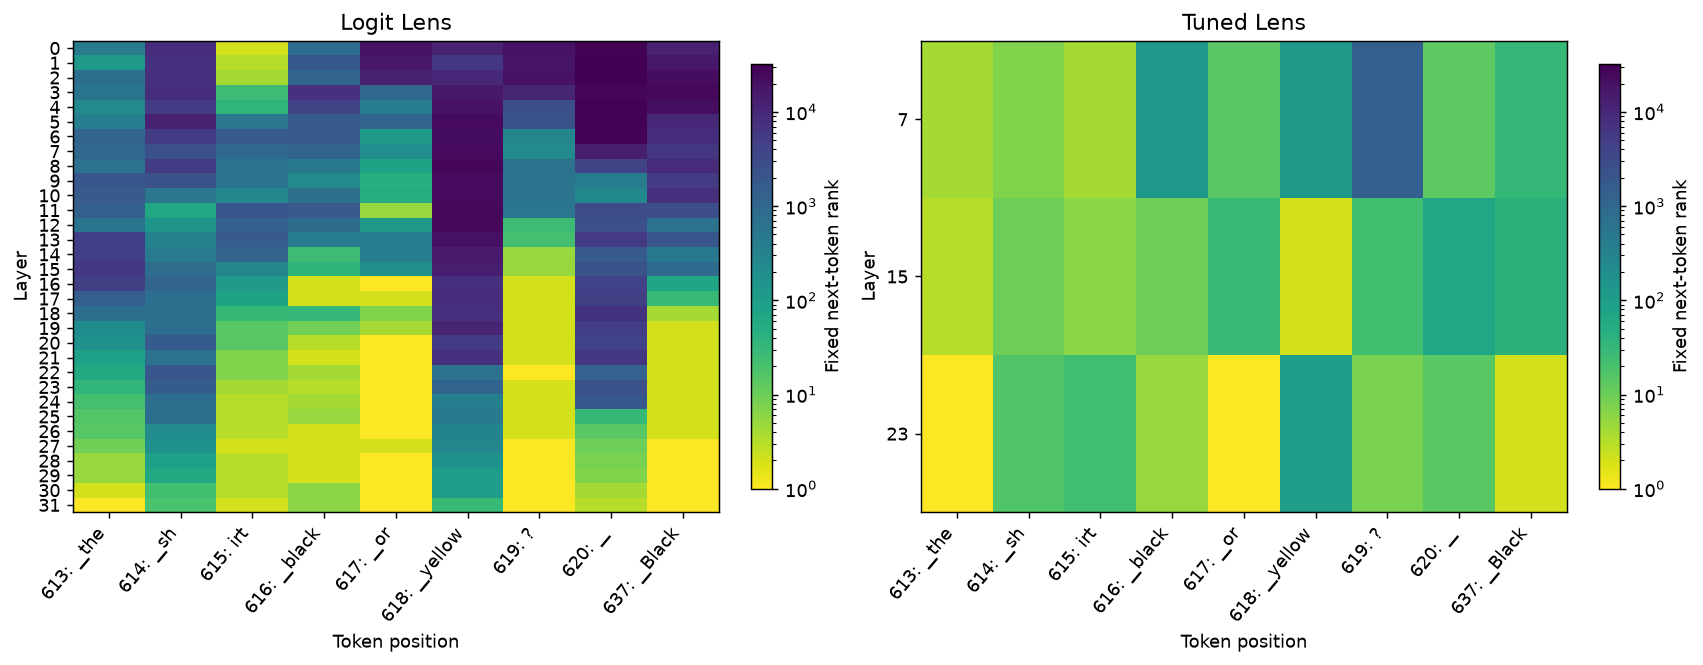

In [2]:
records = [load_snapshot(f"vlm_lens/{sample_id}.json") for sample_id in ("07302654", "19225230")]
for record in records:
    image = load_image(record["sample"]["image_path"])
    ax = plot_input(image, prompt=record["sample"]["question"], answer=record["sample"]["answer"],
                    bounding_boxes=[record["sample"]["bbox_xywh"]])
    show_figure(ax.figure)
    print("Native generated answer:", record["generated_answer"])
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    for ax, method in zip(axes, ["logit", "tuned"]):
        view = record[method]
        labels = [f"{p}: {piece}" for p, piece in zip(view["positions"], view["target_pieces"])]
        plot_lens_heatmap(view["target_ranks"], layer_labels=view["layers"], token_labels=labels,
                         ax=ax, title=method.title() + " Lens", value_label="Fixed next-token rank",
                         vmin=1, vmax=32064)
    show_figure(fig)

**Readout coordinates:** each column is a native prediction position and its fixed next-token target. The final answer may contain multiple subword pieces (for example `Y` + `ellow`). Intermediate top vocabulary predictions are not translated, filtered, or treated as generated answers. The fitted Tuned Lens panels show only the three trained layers; they are evaluated on GQA after COCO caption calibration.

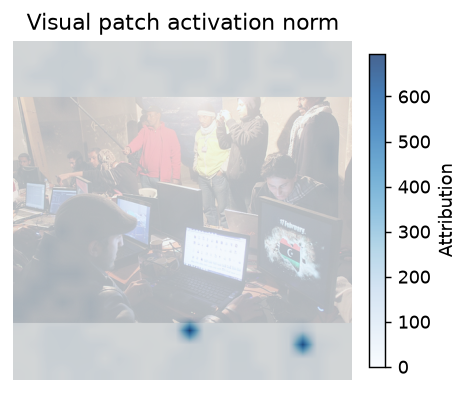

EmbedLens nearest lexical fragments for selected target-region patches:
Patch [7, 12] -> ['▁Blue', '▁blue', 'blue']
Patch [5, 13] -> ['▁person', '▁people', '▁persons']
Patch [5, 12] -> ['▁Blue', '▁blue', 'inta']
Patch [9, 14] -> [None, None, None]


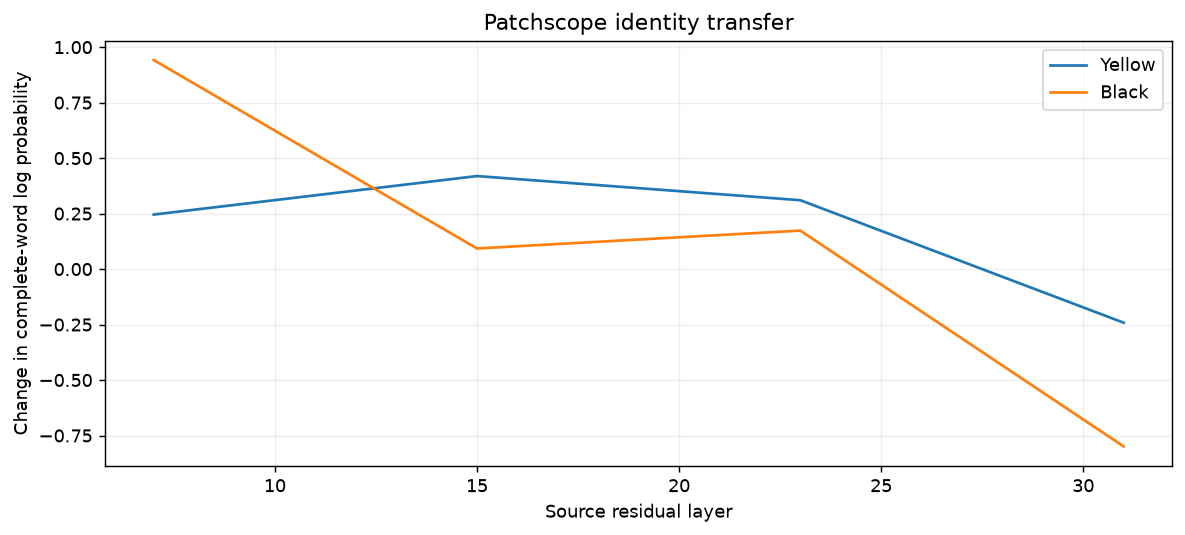

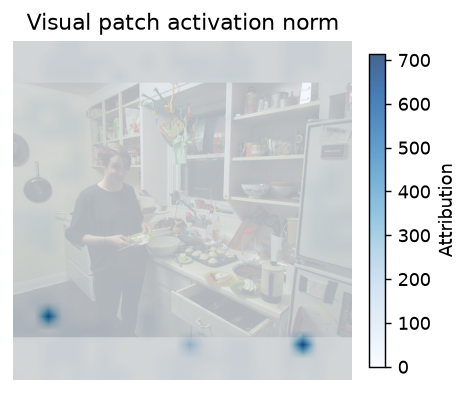

EmbedLens nearest lexical fragments for selected target-region patches:
Patch [16, 6] -> ['▁black', '▁Black', None]
Patch [16, 7] -> ['▁black', '▁Black', None]
Patch [11, 6] -> ['▁black', '▁Black', '▁Patrick']
Patch [12, 7] -> ['▁black', None, None]


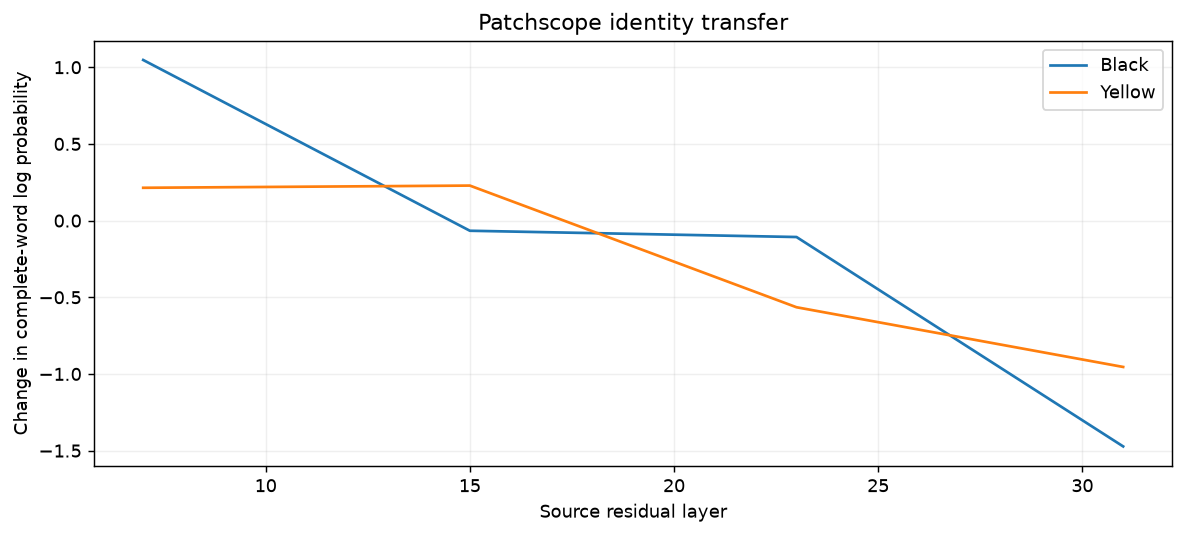

In [3]:
for record in records:
    image, box = gqa_input(record)
    fig, axes = plot_attention_comparison(image, {"Visual patch activation norm": record["embed"]["activation_norms"]},
                                         columns=1, alpha=.75)
    show_figure(fig)
    print("EmbedLens nearest lexical fragments for selected target-region patches:")
    for patch in record["embed"]["top_shirt_fragments"][:4]:
        print("Patch", patch["grid_yx"], "->", patch["pieces"][:3])
    curves = {}
    for word, result in record["patchscope"]["words"].items():
        curves[word] = {"x": record["patchscope"]["source_layers"],
                        "y": np.asarray(result["patched_log_probabilities"]) - np.asarray(result["zero_vector_log_probabilities"])}
    ax = plot_intervention_curves(curves, xlabel="Source residual layer", ylabel="Change in complete-word log probability",
                                  title="Patchscope identity transfer")
    show_figure(ax.figure)

**Scope:** EmbedLens here reports patch norms and nearest vocabulary embeddings; lexical neighbors are associations, not detected object labels or the full sink/dead-token pruning procedure. Patchscope transfers the same residual into a fixed identity-copy context. Its curves measure answer-word support relative to a same-site zero vector, which does not guarantee that the model freely verbalizes that word.

## Optional new model run

This cell is deliberately opt-in. `VLM_PROBING_MODEL` selects a Hugging Face model ID or local checkpoint; `VLM_PROBING_DEVICE` selects the device. Hugging Face uses its normal cache (`HF_HOME` can relocate it). Rerunning performs fresh forwards and may need a GPU. An architecture-specific input adapter may be needed when changing the model; inspect `probe.describe()` first.

In [4]:
if RERUN:
    from demos.runtime import bind_model, gqa_case, fitted_method
    from vlm_probing.metrics import SequenceLogProb
    probe, processor, device = bind_model("llava-hf/llava-1.5-7b-hf")
    sample = records[0]["sample"]
    base, scored, answer_mask, prediction_mask, masks, info = gqa_case(
        probe, processor, sample, ASSETS / "images")
    result = probe.lens.logit(tokens=prediction_mask).run(scored)
    ax = plot_lens_heatmap(result, target_token_id=scored.layout.token_ids[answer_mask].tolist(), title="Fresh Logit Lens")
    show_figure(ax.figure)
    embed = probe.lens.embed(tokens="visual").run(base)
    print("EmbedLens output tensors:", list(embed.tensors))
    if os.environ.get("VLM_PROBING_LENS_CONFIG"):
        tuned = fitted_method(probe, "tuned", tokens=prediction_mask).run(scored)
        print("Fitted Tuned Lens layers:", tuned.metadata["layers"])
    copy_prompt = "red -> red\nblue -> blue\ngreen -> green\nx ->"
    target = dict(processor.tokenizer(copy_prompt, return_tensors="pt").to(device))
    source_position = info["last_position"]
    placeholder = processor.tokenizer.encode("x", add_special_tokens=False)[0]
    locations = (target["input_ids"][0] == placeholder).nonzero().flatten()
    if len(locations) != 1:
        raise ValueError("Identity prompt must contain exactly one x placeholder")
    transfer = probe.lens.patchscope(layers=[max(probe.spec.residuals)//2], source_position=source_position,
                                     target_layer=0, target_position=int(locations[0])).run(base, target_inputs=target)
    print("Fresh Patchscope transfer:", list(transfer.tensors))
else:
    print("Fresh inference skipped.")

Fresh inference skipped.


## Sources and interpretation

**GQA examples:** question 07302654 / image 2341576 and question 19225230 / image 2342134, from the [Cross-modal Information Flow author subset](https://github.com/FightingFighting/cross-modal-information-flow-in-MLLM/tree/main/datasets) and [GQA image archive](https://cs.stanford.edu/people/dorarad/gqa/download.html). **References:** [Tuned Lens](https://arxiv.org/abs/2303.08112), [EmbedLens](https://arxiv.org/abs/2603.00510), [Patchscopes](https://arxiv.org/abs/2404.04414). The fitted Tuned Lens uses 1,024 COCO2014 image-caption training cases and 256 separate validation cases (eight text-prediction positions per image); no GQA display image was used for fitting.

Bundled image and data attribution is listed in [README.md](README.md) and [image notices](assets/images/SOURCE_NOTICES.md). Model checkpoints and fitted lens artifacts are not included.